# Hybrid Airbnb Demand Network

This notebook combines the three standalone model structures into one PyTorch-based hybrid pipeline for predicting high-demand Airbnb listings in New York City.

The pipeline uses:

1. The standalone sentiment model structure: an embedding + LSTM text model trained from VADER sentiment labels.
2. The standalone CNN structure: a map-patch convolutional model trained from latitude/longitude patches.
3. The standalone tabular neural network structure: dense 64 -> dropout -> dense 32 -> dropout -> output.

The final tabular model receives the original structured inputs plus the two auxiliary outputs:

- `sentiment_prob`
- `cnn_demand_prob`

The final target is `high_demand`: listings in the top 25% of `reviews_per_month`.

The auxiliary feature generators are trained on `aux_train_df`, while the final hybrid model is trained on `hybrid_train_df`. This avoids training the final model on auxiliary predictions from models that already saw those exact rows.


## 1. Setup and configuration

In [ ]:
# Install the project dependencies first if needed:
# !pip install -r requirements.txt

import re
import random
import warnings
from collections import Counter
from io import BytesIO
from urllib.request import urlopen

import nltk
import numpy as np
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
from PIL import Image

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


CONFIG = {
    "batch_size": 32,
    "sentiment_epochs": 5,
    "cnn_epochs": 30,
    "tabular_epochs": 20,
    "sentiment_embed_dim": 100,
    "sentiment_hidden_dim": 128,
    "patch_size": 32,
    "sentiment_learning_rate": 1e-3,
    "cnn_learning_rate": 5e-4,
    "tabular_learning_rate": 1e-3,
}

def fetch_url_bytes(url, timeout=20):
    with urlopen(url, timeout=timeout) as response:
        return response.read()

class ArrayDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(np.asarray(X, dtype=np.float32), dtype=torch.float32)
        self.y = None if y is None else torch.tensor(np.asarray(y, dtype=np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

class TabularNN(nn.Module):
    """PyTorch equivalent of the standalone Keras tabular network."""
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def train_tabular_nn(model, X_train, y_train, X_val, y_val, *, epochs, model_name):
    train_loader = DataLoader(ArrayDataset(X_train, y_train), batch_size=CONFIG["batch_size"], shuffle=True)
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["tabular_learning_rate"])

    for epoch in range(epochs):
        model.train()
        losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = criterion(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        val_prob = predict_binary_prob(model, X_val)
        val_pred = (val_prob >= 0.5).astype(int)
        val_auc = roc_auc_score(y_val, val_prob) if len(np.unique(y_val)) > 1 else np.nan
        val_acc = accuracy_score(y_val, val_pred)
        print(f"{model_name} epoch {epoch + 1}/{epochs} - loss={np.mean(losses):.4f}, val_acc={val_acc:.4f}, val_auc={val_auc:.4f}")

    return model

def predict_binary_prob(model, X):
    loader = DataLoader(ArrayDataset(X), batch_size=CONFIG["batch_size"], shuffle=False)
    model.eval()
    probs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(DEVICE)
            probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
    return np.asarray(probs, dtype=np.float32)

CONFIG


Using device: cpu


{'batch_size': 32,
 'sentiment_epochs': 5,
 'cnn_epochs': 30,
 'tabular_epochs': 20,
 'sentiment_embed_dim': 100,
 'sentiment_hidden_dim': 128,
 'patch_size': 32,
 'sentiment_learning_rate': 0.001,
 'cnn_learning_rate': 0.0005,
 'tabular_learning_rate': 0.001}

## 2. Load Data

The notebook uses the public AB_NYC_2019 dataset directly from one source.


In [ ]:
DATA_URL = "https://rossbulat.com/data/ab_nyc_2019.csv"

def load_airbnb_data(url=DATA_URL):
    print(f"Loading dataset: {url}")
    return pd.read_csv(BytesIO(fetch_url_bytes(url))), url

raw_df, data_source = load_airbnb_data()

print("Loaded source:", data_source)
print("Shape:", raw_df.shape)
raw_df.head()


Loading dataset: https://rossbulat.com/data/ab_nyc_2019.csv
Loaded source: https://rossbulat.com/data/ab_nyc_2019.csv
Shape: (48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 3. Preprocessing and Target Creation

This keeps only the columns needed by the model, fills missing review rates, removes invalid prices, and creates the high-demand target.


In [ ]:
raw_df.head

<bound method NDFrame.head of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

           host_name neighbourhood_group       neighbourhood  latitude  \
0               John            Brooklyn          Kensington  40.64749   
1           Jennifer           Manhattan             Midtown  40.75362   
2          Elisabeth           Manhattan              Harlem  40.80902   
3        LisaRoxanne            Brooklyn        Clinton Hill  40.68514   
4              Laura           Manhattan         East Harlem  40.79851   
...              ...                 ...                 ...       ...   
48890        Sabrina            Brooklyn  Bedford-Stuyvesant  40.67853   
48891        Marisol            Brooklyn            Bushwick  40.70184   
48892  Ilgar & Aysel           Manhattan              Harlem  40.81475   
48893            Taz           Manhattan      Hell's Kitchen  40.75751   
48894     Christophe           Manhattan      Hell's Kitchen  40.76404   

       longitude        room_type  price  minimum_nights  number_of_reviews  \
0      -73.97237     Private room    149               1                  9   
1      -73.98377  Entire home/apt    225               1                 45   
2      -73.94190     Private room    150               3                  0   
3      -73.95976  Entire home/apt     89               1                270   
4      -73.94399  Entire home/apt     80              10                  9   
...          ...              ...    ...             ...                ...   
48890  -73.94995     Private room     70               2                  0   
48891  -73.93317     Private room     40               4                  0   
48892  -73.94867  Entire home/apt    115              10                  0   
48893  -73.99112      Shared room     55               1                  0   
48894  -73.98933     Private room     90               7                  0   

      last_review  reviews_per_month  calculated_host_listings_count  \
0      2018-10-19               0.21                               6   
1      2019-05-21               0.38                               2   
2             NaN                NaN                               1   
3      2019-07-05               4.64                               1   
4      2018-11-19               0.10                               1   
...           ...                ...                             ...   
48890         NaN                NaN                               2   
48891         NaN                NaN                               2   
48892         NaN                NaN                               1   
48893         NaN                NaN                               6   
48894         NaN                NaN                               1   

       availability_365  
0                   365  
1                   355  
2                   365  
3                   194  
4                     0  
...                 ...  
48890                 9  
48891                36  
48892                27  
48893                 2  
48894               

In [ ]:
raw_df.info()  # examine columns and data types; data types are as expected except last review (string cf datetime)
# neighbourhood group, neighbourhood and room type should be made to catagorical value (see later)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
skewness = raw_df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
skewness

,0
minimum_nights,21.827275
price,19.118939
calculated_host_listings_count,7.933174
number_of_reviews,3.690635
reviews_per_month,3.130189
longitude,1.284210
host_id,1.206214
availability_365,0.763408
latitude,0.237167
id,-0.090257


In [ ]:
raw_df.isnull().sum() # a large number of reviews per month are missing, do these correspond to number of reviews = 0 or just missing data?

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
missing_reviews = raw_df[raw_df["reviews_per_month"].isnull()]
missing_reviews["number_of_reviews"].value_counts().head(10)

,count
number_of_reviews,
0,10052


In [ ]:
#confirms that where reviews_per_month is missing it is because number of reviews = 0;
# therefore replace with 0

In [ ]:
raw_df["reviews_per_month"] = raw_df["reviews_per_month"].fillna(0)

In [ ]:
raw_df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
# Examine price variable,

In [ ]:
# some listings have price = 0; how many?

In [ ]:
(raw_df["price"] == 0).sum()

np.int64(11)

In [ ]:
# as 11 have price == 0 this is very small percentage, therefore remove

In [ ]:
raw_df = raw_df[raw_df["price"] > 0]

In [ ]:
#potential outliers in price (min and max), minimum nights (max).

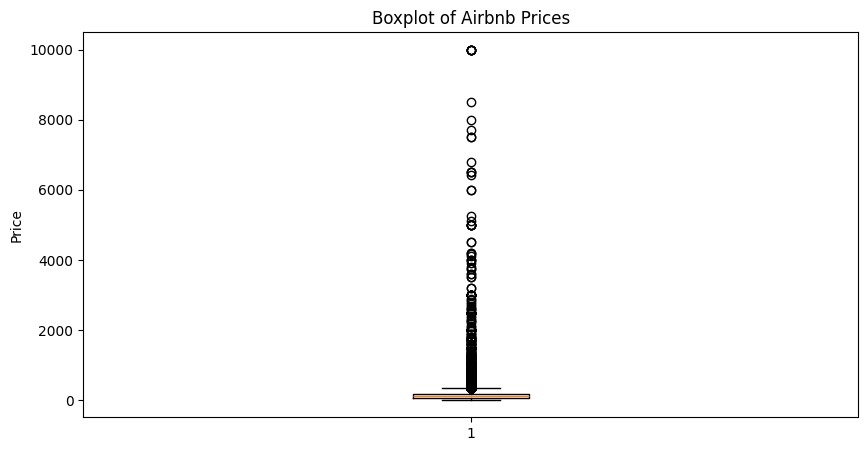

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.boxplot(raw_df['price'])
plt.title('Boxplot of Airbnb Prices')
plt.ylabel('Price')
plt.show()

In [ ]:
raw_df["price"].describe(percentiles=[0.90, 0.95, 0.99])

,price
count,48884.000000
mean,152.755053
std,240.170260
min,10.000000
50%,106.000000
90%,269.000000
95%,355.000000
99%,799.000000
max,10000.000000


In [ ]:
raw_df.sort_values(by="price", ascending=False)[
    ["name", "neighbourhood_group", "room_type", "price"]
].head(20)

,name,neighbourhood_group,room_type,price
9151,Furnished room in Astoria apartment,Queens,Private room,10000
17692,Luxury 1 bedroom apt. -stunning Manhattan views,Brooklyn,Entire home/apt,10000
29238,1-BR Lincoln Center,Manhattan,Entire home/apt,10000
12342,"Quiet, Clean, Lit @ LES & Chinatown",Manhattan,Private room,9999
40433,2br - The Heart of NYC: Manhattans Lower East ...,Manhattan,Entire home/apt,9999
6530,Spanish Harlem Apt,Manhattan,Entire home/apt,9999
30268,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,Manhattan,Entire home/apt,8500
4377,Film Location,Brooklyn,Entire home/apt,8000
29662,East 72nd Townhouse by (Hidden by Airbnb),Manhattan,Entire home/apt,7703
45666,Gem of east Flatbush,Brooklyn,Private room,7500


In [ ]:
# these appear to be genuine data sets for luxury appartments, therefore retain and use a log transformation (price == 0 is already removed)
raw_df["price_log"] = np.log1p(raw_df["price"])

In [ ]:
# examine min nights

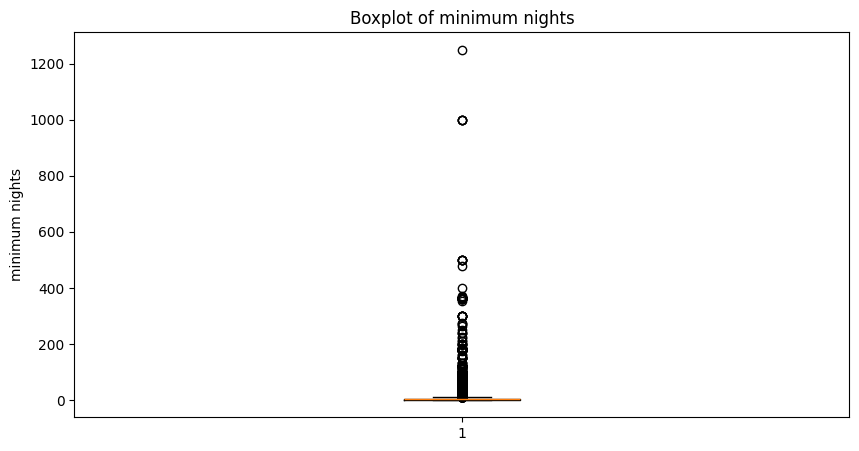

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
plt.boxplot(raw_df['minimum_nights'])
plt.title('Boxplot of minimum nights')
plt.ylabel('minimum nights')
plt.show()

In [ ]:
raw_df["minimum_nights"].describe(percentiles=[0.90, 0.95, 0.99])

,minimum_nights
count,48884.000000
mean,7.029887
std,20.512224
min,1.000000
50%,3.000000
90%,28.000000
95%,30.000000
99%,45.000000
max,1250.000000


In [ ]:
# suggest have a cap at the 99th centile as these extreme values are likely to be outliers for various (unknown) reasons

In [ ]:
upper_cap = raw_df["minimum_nights"].quantile(0.99)

raw_df["minimum_nights"] = np.where(
    raw_df["minimum_nights"] > upper_cap,
    upper_cap,
    raw_df["minimum_nights"]
)

In [ ]:
# examine availability
#note, we do not know exactly what this variable means (fully booked vs not available by host)
#therefore i think we should retain all data



In [ ]:
(raw_df["availability_365"] == 0).sum()

np.int64(17530)

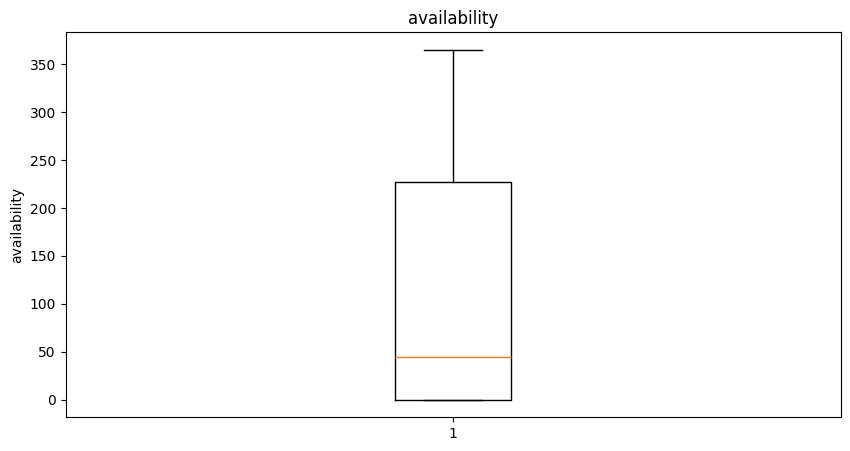

In [ ]:
plt.figure(figsize=(10, 5))
plt.boxplot(raw_df['availability_365'])
plt.title('availability')
plt.ylabel('availability')
plt.show()

In [ ]:
#given distribution and only mild skewness (see above) I would keep values as raw data. no further transformations required
# this is to preserve potential non linear effects and not lose patterns by grouping.

In [ ]:
raw_df.describe(include='object')  # examine non numberical data

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48868,48863,48884,48884,48884,38833
unique,47894,11450,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21660,3919,25407,1412


In [ ]:
# examine calculated_host_listings_count
# very skewed data set, no missing values.
# log trasnform

In [ ]:
raw_df["host_listings_log"] = np.log1p(
    raw_df["calculated_host_listings_count"]
)

In [ ]:
# examine longitude and latitude variables

In [ ]:
raw_df[["latitude", "longitude"]].describe()

,latitude,longitude
count,48884.000000,48884.000000
mean,40.728953,-73.952176
std,0.054532,0.046159
min,40.499790,-74.244420
25%,40.690100,-73.983080
50%,40.723080,-73.955685
75%,40.763120,-73.936290
max,40.913060,-73.712990


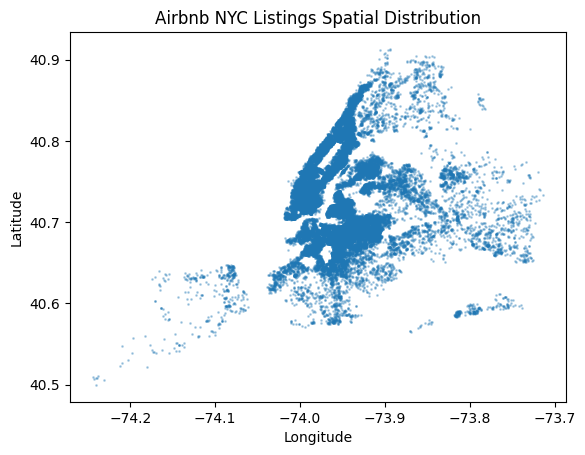

In [ ]:
import matplotlib.pyplot as plt # viewing distribution to check data spread (replica of graph Ross produced in the intro

plt.scatter(raw_df["longitude"], raw_df["latitude"], s=1, alpha=0.3)
plt.title("Airbnb NYC Listings Spatial Distribution")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
# these look as expected; no outliers found, no values missing as previously shown
# data can be used as is for scaling.

In [ ]:
# Classify high demand properties as defined by Ross (i.e. top 25% of reviews_per_month)
raw_df["high_demand"] = (raw_df["reviews_per_month"] >= raw_df["reviews_per_month"].quantile(0.75)).astype(int)

In [ ]:
raw_df["high_demand"].value_counts(normalize=True) # check of proportions for high demand.  Look good!

,proportion
high_demand,
0,0.748732
1,0.251268


In [ ]:
raw_df.groupby("neighbourhood_group")["high_demand"].mean() # just checking how the demand looks across neighbourhoods.

,high_demand
neighbourhood_group,
Bronx,0.371560
Brooklyn,0.247375
Manhattan,0.220406
Queens,0.350688
Staten Island,0.391421


In [ ]:
raw_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,price_log,host_listings_log,high_demand
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1.0,9,2018-10-19,0.21,6,365,5.010635,1.945910,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1.0,45,2019-05-21,0.38,2,355,5.420535,1.098612,0
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3.0,0,NaN,0.00,1,365,5.017280,0.693147,0
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1.0,270,2019-07-05,4.64,1,194,4.499810,0.693147,1
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10.0,9,2018-11-19,0.10,1,0,4.394449,0.693147,0


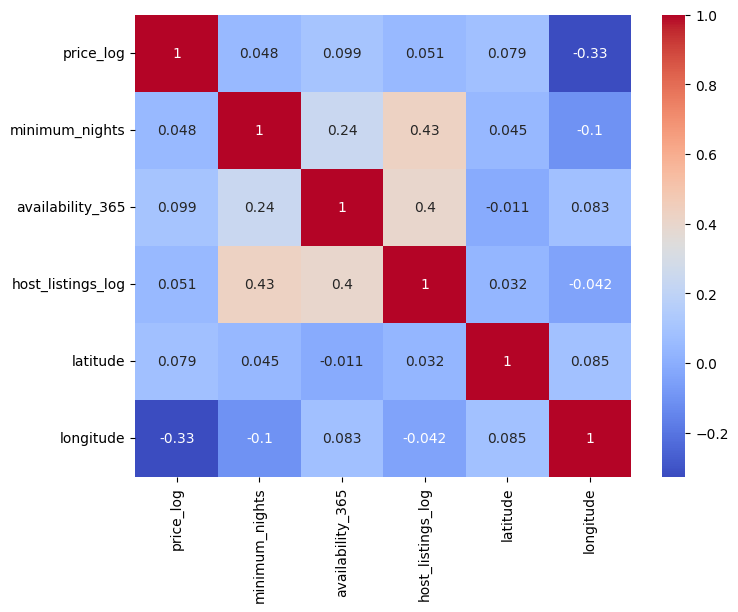

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(raw_df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
TEXT_COLS = ["name", "host_name", "neighbourhood", "neighbourhood_group"]
NUMERIC_INPUTS = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]
CATEGORICAL_INPUTS = ["room_type"]
OPTIONAL_OUTPUT_COLS = ["id"]

REQUIRED_COLUMNS = TEXT_COLS + NUMERIC_INPUTS + CATEGORICAL_INPUTS
missing_cols = [c for c in REQUIRED_COLUMNS if c not in raw_df.columns]
if missing_cols:
    raise ValueError(f"Dataset is missing required columns: {missing_cols}")

keep_cols = [c for c in OPTIONAL_OUTPUT_COLS + REQUIRED_COLUMNS if c in raw_df.columns]
df = raw_df[keep_cols].copy()

for col in NUMERIC_INPUTS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[TEXT_COLS + CATEGORICAL_INPUTS] = df[TEXT_COLS + CATEGORICAL_INPUTS].fillna("").astype(str)
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
df = df.dropna(subset=[c for c in NUMERIC_INPUTS if c != "reviews_per_month"])
df = df[df["price"] > 0].copy()

df["price_log"] = np.log1p(df["price"])
df["host_listings_log"] = np.log1p(df["calculated_host_listings_count"])
df["combined_text"] = df[TEXT_COLS].agg(" ".join, axis=1)

# Match the standalone tabular notebook: cap minimum_nights at the full-data 99th percentile.
minimum_nights_cap = df["minimum_nights"].quantile(0.99)
df["minimum_nights"] = df["minimum_nights"].clip(upper=minimum_nights_cap)

demand_threshold = df["reviews_per_month"].quantile(0.75)
df["high_demand"] = (df["reviews_per_month"] >= demand_threshold).astype(int)

print("Demand threshold:", demand_threshold)
print("Minimum nights 99th percentile cap:", minimum_nights_cap)
print("Final dataframe shape:", df.shape)
print(df["high_demand"].value_counts(normalize=True).rename("proportion"))

Demand threshold: 1.58
Minimum nights 99th percentile cap: 45.0
Final dataframe shape: (48884, 17)
high_demand
0    0.748732
1    0.251268
Name: proportion, dtype: float64


## 4. Train/test split and anti-leakage split

The final hybrid model is evaluated only on `test_df`.

The training data is split again into:

- `aux_train_df`: trains the sentiment and CNN feature generators.
- `hybrid_train_df`: trains the final tabular NN using the generated auxiliary features.

This is simpler than full out-of-fold stacking and avoids training the final NN on auxiliary predictions from models trained on the same rows.

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["high_demand"],
    random_state=SEED,
)

aux_train_df, hybrid_train_df = train_test_split(
    train_df,
    test_size=0.5,
    stratify=train_df["high_demand"],
    random_state=SEED,
)

for name, frame in [("aux_train_df", aux_train_df), ("hybrid_train_df", hybrid_train_df), ("test_df", test_df)]:
    print(name, frame.shape, frame["high_demand"].mean())


aux_train_df (19553, 17) 0.251265790415793
hybrid_train_df (19554, 17) 0.25125294057481845
test_df (9777, 17) 0.2513040810064437


## 5. Sentiment LSTM Feature Generator

This section keeps the standalone sentiment model structure: VADER labels, token ids, padded batches, an embedding layer, one LSTM, and a final linear output layer. The trained model's probability output becomes `sentiment_prob`.


In [ ]:
def basic_tokenizer(text):
    return re.findall(r"\b\w+\b", str(text).lower())

try:
    nltk.data.find("sentiment/vader_lexicon.zip")
except LookupError:
    nltk.download("vader_lexicon", quiet=True)

sentiment_analyzer = SentimentIntensityAnalyzer()

def sentiment_label_from_text(text):
    return int(sentiment_analyzer.polarity_scores(str(text))["compound"] > 0)

aux_sentiment_labels = aux_train_df["combined_text"].apply(sentiment_label_from_text).astype(int).values
print("Sentiment label distribution on aux_train_df:", pd.Series(aux_sentiment_labels).value_counts(normalize=True).to_dict())


Sentiment label distribution on aux_train_df: {0: 0.5700404030072111, 1: 0.42995959699278885}


In [ ]:
all_tokens = []
for text in aux_train_df["combined_text"]:
    all_tokens.extend(basic_tokenizer(text))

vocab = {tok: idx + 1 for idx, tok in enumerate(set(all_tokens))}
unk_index = 0
vocab_size = len(vocab) + 1

class TextDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = list(texts)
        self.labels = None if labels is None else np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = basic_tokenizer(self.texts[idx])
        ids = torch.tensor([vocab.get(tok, unk_index) for tok in tokens], dtype=torch.long)
        if len(ids) == 0:
            ids = torch.tensor([unk_index], dtype=torch.long)
        if self.labels is None:
            return ids
        return ids, torch.tensor(self.labels[idx], dtype=torch.float32)

def collate_text_batch(batch):
    if isinstance(batch[0], tuple):
        texts, labels = zip(*batch)
        texts = nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=unk_index)
        labels = torch.stack(labels)
        return texts, labels
    return nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=unk_index)

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=unk_index)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        return self.fc(hidden[-1]).squeeze(1)

sentiment_model = SentimentModel(
    vocab_size,
    embed_dim=CONFIG["sentiment_embed_dim"],
    hidden_dim=CONFIG["sentiment_hidden_dim"],
).to(DEVICE)

print("Vocabulary size:", vocab_size)
sentiment_model


Vocabulary size: 10397


SentimentModel(
  (embedding): Embedding(10397, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
sent_train_text, sent_val_text, sent_train_y, sent_val_y = train_test_split(
    aux_train_df["combined_text"].tolist(),
    aux_sentiment_labels.tolist(),
    test_size=0.2,
    stratify=aux_sentiment_labels if len(np.unique(aux_sentiment_labels)) > 1 else None,
    random_state=SEED,
)

sent_train_loader = DataLoader(
    TextDataset(sent_train_text, sent_train_y),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    collate_fn=collate_text_batch,
)
sent_val_loader = DataLoader(
    TextDataset(sent_val_text, sent_val_y),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    collate_fn=collate_text_batch,
)

criterion_sent = nn.BCEWithLogitsLoss()
optimizer_sent = torch.optim.Adam(sentiment_model.parameters(), lr=CONFIG["sentiment_learning_rate"])

for epoch in range(CONFIG["sentiment_epochs"]):
    sentiment_model.train()
    losses = []
    for texts, labels in sent_train_loader:
        texts, labels = texts.to(DEVICE), labels.to(DEVICE)
        loss = criterion_sent(sentiment_model(texts), labels)
        optimizer_sent.zero_grad()
        loss.backward()
        optimizer_sent.step()
        losses.append(loss.item())

    sentiment_model.eval()
    val_true, val_pred = [], []
    with torch.no_grad():
        for texts, labels in sent_val_loader:
            texts = texts.to(DEVICE)
            preds = (torch.sigmoid(sentiment_model(texts)).cpu() >= 0.5).float()
            val_true.extend(labels.tolist())
            val_pred.extend(preds.tolist())
    val_acc = accuracy_score(val_true, val_pred)
    print(f"Sentiment epoch {epoch + 1}/{CONFIG['sentiment_epochs']} - loss={np.mean(losses):.4f}, val_acc={val_acc:.4f}")


Sentiment epoch 1/5 - loss=0.4652, val_acc=0.9031
Sentiment epoch 2/5 - loss=0.2184, val_acc=0.9397
Sentiment epoch 3/5 - loss=0.1409, val_acc=0.9535
Sentiment epoch 4/5 - loss=0.1015, val_acc=0.9573
Sentiment epoch 5/5 - loss=0.0775, val_acc=0.9588


### Sentiment Model Performance Metrics

In [515]:
def predict_sentiment_prob(texts):
    loader = DataLoader(
        TextDataset(texts, labels=None),
        batch_size=CONFIG["batch_size"],
        shuffle=False,
        collate_fn=collate_text_batch,
    )
    sentiment_model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            probs.extend(torch.sigmoid(sentiment_model(batch)).cpu().numpy())
    return np.asarray(probs, dtype=np.float32)

# Ensure we are working on fresh copies to avoid SettingWithCopyWarnings
hybrid_train_df = hybrid_train_df.copy()
test_df = test_df.copy()

print("Generating sentiment features...")
hybrid_train_df["sentiment_prob"] = predict_sentiment_prob(hybrid_train_df["combined_text"])
test_df["sentiment_prob"] = predict_sentiment_prob(test_df["combined_text"])


# Verify the columns exist before proceeding
print(f"Columns in hybrid_train_df: {hybrid_train_df.columns.tolist()}")
display(hybrid_train_df[["sentiment_prob"]].head())

Generating sentiment features...
Columns in hybrid_train_df: ['id', 'name', 'host_name', 'neighbourhood', 'neighbourhood_group', 'latitude', 'longitude', 'price', 'minimum_nights', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'room_type', 'price_log', 'host_listings_log', 'combined_text', 'high_demand', 'sentiment_prob']


,sentiment_prob
43514,0.002621
37613,0.002632
30040,0.993460
22924,0.995411
19981,0.002565


Sentiment Model Validation ROC-AUC: 0.9813


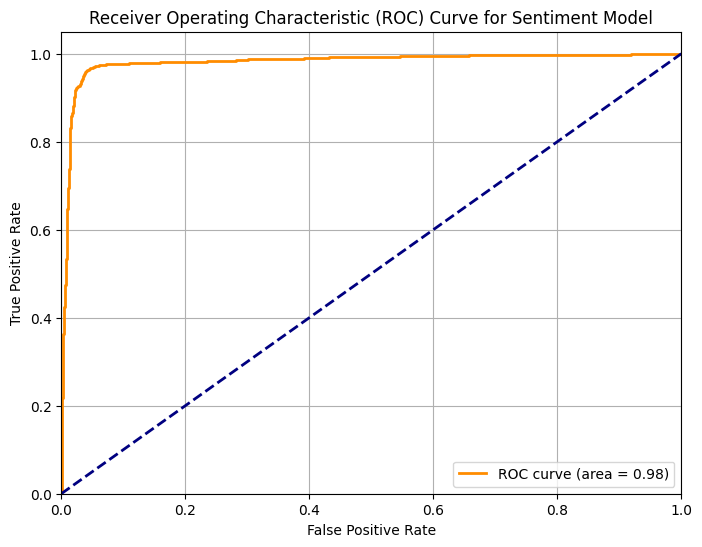


Sentiment Model Validation Confusion Matrix:
[[2145   84]
 [  77 1605]]


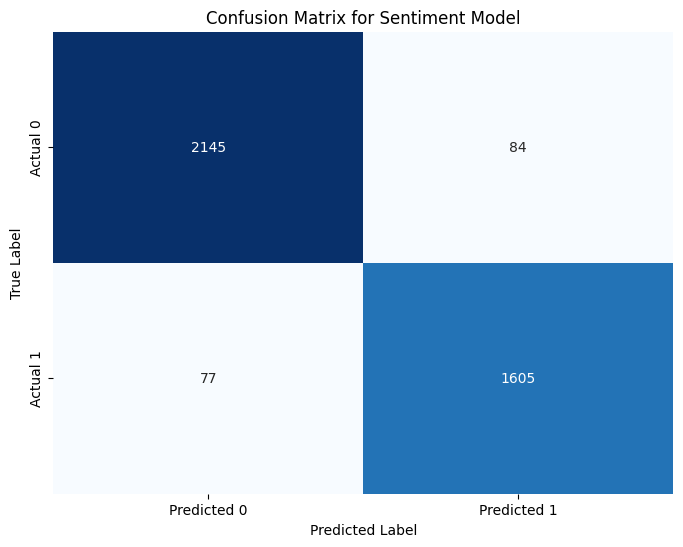

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


# Get true labels and predicted probabilities for the validation set
val_true_labels = np.asarray(sent_val_y, dtype=np.float32)
val_probs = predict_sentiment_prob(sent_val_text)
val_preds = (val_probs >= 0.5).astype(int)

# Calculate ROC AUC score
roc_auc = roc_auc_score(val_true_labels, val_probs)
print(f"Sentiment Model Validation ROC-AUC: {roc_auc:.4f}")

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(val_true_labels, val_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Sentiment Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Calculate and plot Confusion Matrix
cm = confusion_matrix(val_true_labels, val_preds)
print("\nSentiment Model Validation Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Sentiment Model')
plt.show()

## 6. CNN Map-Patch Feature Generator

This section keeps the standalone CNN structure, converted from Keras to PyTorch: two Conv2D + ReLU + MaxPool blocks, global average pooling, a dense 32-unit classifier layer, dropout 0.3, and one binary output. The trained model's probability output becomes `cnn_demand_prob`.


In [ ]:
MAP_URL = "https://raw.githubusercontent.com/luitoz/machile-learning-team-project/refs/heads/main/New_York_City_.jpg"

IMG = Image.open(BytesIO(fetch_url_bytes(MAP_URL))).convert("L")
IMG_ARR = np.array(IMG)
H, W = IMG_ARR.shape

lat_min, lat_max = 40.5, 40.92
lon_min, lon_max = -74.25, -73.7
PATCH_SIZE = CONFIG["patch_size"]

def latlon_to_pixel(lat, lon):
    x = (lon - lon_min) / (lon_max - lon_min)
    y = (lat_max - lat) / (lat_max - lat_min)
    px = int(x * (W - 1))
    py = int(y * (H - 1))
    return px, py

def extract_patch(px, py):
    half = PATCH_SIZE // 2
    x1 = max(px - half, 0)
    x2 = min(px + half, W)
    y1 = max(py - half, 0)
    y2 = min(py + half, H)
    patch = IMG_ARR[y1:y2, x1:x2]
    patch = Image.fromarray(patch).resize((PATCH_SIZE, PATCH_SIZE))
    return np.array(patch)

def make_patches(frame):
    patches = []
    for _, row in frame.iterrows():
        px, py = latlon_to_pixel(row["latitude"], row["longitude"])
        patches.append(extract_patch(px, py))
    arr = np.array(patches).astype("float32") / 255.0
    return arr[:, None, :, :]

print("Map image shape:", IMG_ARR.shape)
print("Patch size:", PATCH_SIZE)


Map image shape: (1291, 1326)
Patch size: 32


In [ ]:
class PatchDataset(Dataset):
    def __init__(self, patches, labels=None):
        self.patches = torch.tensor(patches, dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels, dtype=np.float32), dtype=torch.float32)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        if self.labels is None:
            return self.patches[idx]
        return self.patches[idx], self.labels[idx]

class MapPatchCNN(nn.Module):
    """PyTorch equivalent of the standalone Keras map-patch CNN."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

cnn_model = MapPatchCNN().to(DEVICE)
cnn_model


MapPatchCNN(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=32, out_features=32, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.3, inplace=False)
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [ ]:
cnn_train_df, cnn_val_df = train_test_split(
    aux_train_df,
    test_size=0.2,
    stratify=aux_train_df["high_demand"],
    random_state=SEED,
)

print("Extracting image patches... this may take a moment.")
X_cnn_train = make_patches(cnn_train_df)
y_cnn_train = cnn_train_df["high_demand"].values.astype(np.float32)
X_cnn_val = make_patches(cnn_val_df)
y_cnn_val = cnn_val_df["high_demand"].values.astype(np.float32)

cnn_train_loader = DataLoader(
    PatchDataset(X_cnn_train, y_cnn_train),
    batch_size=CONFIG["batch_size"],
    shuffle=True,
)
cnn_val_loader = DataLoader(
    PatchDataset(X_cnn_val, y_cnn_val),
    batch_size=CONFIG["batch_size"],
    shuffle=False,
)

pos = y_cnn_train.sum()
neg = len(y_cnn_train) - pos
pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=DEVICE)
criterion_cnn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=CONFIG["cnn_learning_rate"])

best_state = None
best_val_loss = np.inf
patience = 2
patience_used = 0

# Reduced epochs for faster execution
FAST_EPOCHS = 5
print(f"Starting CNN training for {FAST_EPOCHS} epochs...")

for epoch in range(FAST_EPOCHS):
    cnn_model.train()
    losses = []
    for patches, labels in cnn_train_loader:
        patches, labels = patches.to(DEVICE), labels.to(DEVICE)
        loss = criterion_cnn(cnn_model(patches), labels)
        optimizer_cnn.zero_grad()
        loss.backward()
        optimizer_cnn.step()
        losses.append(loss.item())

    cnn_model.eval()
    val_losses, val_true, val_prob = [], [], []
    with torch.no_grad():
        for patches, labels in cnn_val_loader:
            patches, labels_device = patches.to(DEVICE), labels.to(DEVICE)
            logits = cnn_model(patches)
            val_losses.append(criterion_cnn(logits, labels_device).item())
            val_prob.extend(torch.sigmoid(logits).cpu().numpy())
            val_true.extend(labels.numpy())

    val_loss = float(np.mean(val_losses))
    val_pred = (np.array(val_prob) >= 0.5).astype(int)
    val_auc = roc_auc_score(val_true, val_prob) if len(np.unique(val_true)) > 1 else np.nan
    val_acc = accuracy_score(val_true, val_pred)
    print(f"CNN epoch {epoch + 1}/{FAST_EPOCHS} - loss={np.mean(losses):.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_auc={val_auc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in cnn_model.state_dict().items()}
        patience_used = 0
    else:
        patience_used += 1
        if patience_used >= patience:
            print("CNN early stopping")
            break

if best_state is not None:
    cnn_model.load_state_dict(best_state)

Extracting image patches... this may take a moment.
Starting CNN training for 5 epochs...
CNN epoch 1/5 - loss=1.0394, val_loss=1.0360, val_acc=0.7397, val_auc=0.4871
CNN epoch 2/5 - loss=1.0386, val_loss=1.0360, val_acc=0.7487, val_auc=0.5224
CNN epoch 3/5 - loss=1.0384, val_loss=1.0354, val_acc=0.7487, val_auc=0.5263
CNN epoch 4/5 - loss=1.0379, val_loss=1.0355, val_acc=0.7487, val_auc=0.5288
CNN epoch 5/5 - loss=1.0377, val_loss=1.0351, val_acc=0.5045, val_auc=0.5307


In [516]:
def predict_cnn_prob(frame):
    patches = make_patches(frame)
    loader = DataLoader(PatchDataset(patches), batch_size=CONFIG["batch_size"], shuffle=False)
    cnn_model.eval()
    probs = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            probs.extend(torch.sigmoid(cnn_model(batch)).cpu().numpy())
    return np.asarray(probs, dtype=np.float32)

hybrid_train_df["cnn_demand_prob"] = predict_cnn_prob(hybrid_train_df)
test_df["cnn_demand_prob"] = predict_cnn_prob(test_df)

print(hybrid_train_df[["latitude", "longitude", "cnn_demand_prob"]].head())


       latitude  longitude  cnn_demand_prob
43514  40.76449  -73.99107         0.500755
37613  40.80246  -73.95737         0.492968
30040  40.72605  -74.00072         0.499613
22924  40.67101  -73.94543         0.502206
19981  40.76375  -73.94856         0.483788


### CNN Model Performance Metrics

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels and predicted probabilities for the validation set
val_true_labels_cnn = y_cnn_val # Already np.float32
val_probs_cnn = predict_binary_prob(cnn_model, X_cnn_val)
val_preds_cnn = (val_probs_cnn >= 0.5).astype(int)

# Calculate ROC AUC score
roc_auc_cnn = roc_auc_score(val_true_labels_cnn, val_probs_cnn)
print(f"CNN Model Validation ROC-AUC: {roc_auc_cnn:.4f}")

# Plot ROC Curve
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(val_true_labels_cnn, val_probs_cnn)
plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_cnn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for CNN Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Calculate and plot Confusion Matrix
cm_cnn = confusion_matrix(val_true_labels_cnn, val_preds_cnn)
print("\nCNN Model Validation Confusion Matrix:")
print(cm_cnn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN Model')
plt.show()

### Sample CNN Model Classifications

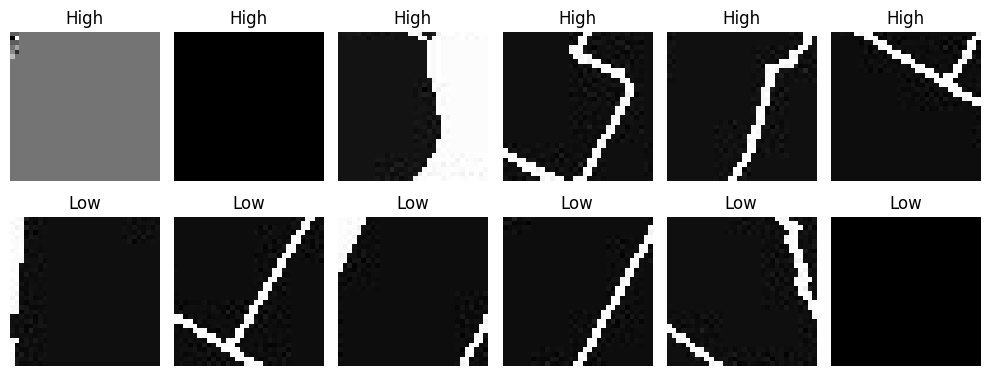

In [524]:
high = X_cnn_val[y_cnn_val == 1]
low = X_cnn_val[y_cnn_val == 0]

plt.figure(figsize=(10,4))

for i in range(6):
    # High demand samples
    plt.subplot(2, 6, i + 1)
    plt.imshow(high[i].squeeze(), cmap="gray")
    plt.title("High")
    plt.axis("off")

    # Low demand samples
    plt.subplot(2, 6, i + 7)
    plt.imshow(low[i].squeeze(), cmap="gray")
    plt.title("Low")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Predicted Demand Heatmap

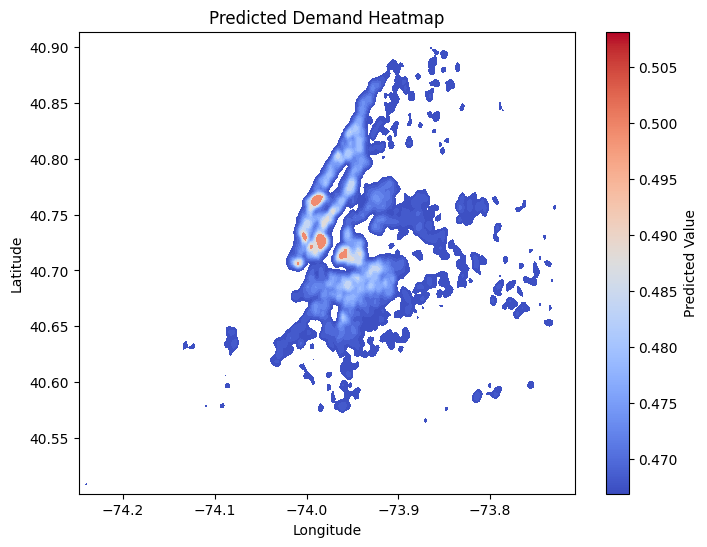

In [517]:
# smoothed heatmap for better visualization
import seaborn as sns

fig, ax = plt.subplots(figsize=(8,6))

sns.kdeplot(
    x=df["longitude"],
    y=df["latitude"],
    weights=hybrid_train_df["cnn_demand_prob"],
    cmap="coolwarm",
    fill=True,
    bw_adjust=0.2, #sharper. more detailed peaks
    levels=15 #finer details
)


# Create colorbar
import matplotlib.cm as cm
import matplotlib.colors as mcolors

norm = mcolors.Normalize(vmin=hybrid_train_df["cnn_demand_prob"].min(),
                         vmax=hybrid_train_df["cnn_demand_prob"].max())
sm = cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="Predicted Value")

plt.title("Predicted Demand Heatmap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

## 7. Final Hybrid Tabular PyTorch Model

The final PyTorch tabular classifier keeps the standalone tabular neural network structure and receives original tabular inputs plus `sentiment_prob` and `cnn_demand_prob`.


In [518]:
BASE_NUMERIC_FEATURES = [
    "price_log",
    "minimum_nights",
    "availability_365",
    "longitude",
    "latitude",
    "host_listings_log",
]

AUX_FEATURES = [
    "sentiment_prob",
    "cnn_demand_prob",
]

CATEGORICAL_FEATURES = [
    "neighbourhood_group",
    "room_type",
]

HYBRID_FEATURES = BASE_NUMERIC_FEATURES + AUX_FEATURES + CATEGORICAL_FEATURES
BASELINE_FEATURES = BASE_NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "high_demand"

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

def build_preprocessor(feature_cols):
    numeric_cols = [c for c in feature_cols if c in BASE_NUMERIC_FEATURES + AUX_FEATURES]
    categorical_cols = [c for c in feature_cols if c in CATEGORICAL_FEATURES]
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_cols),
            ("cat", make_one_hot_encoder(), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

hybrid_preprocessor = build_preprocessor(HYBRID_FEATURES)
X_hybrid = hybrid_preprocessor.fit_transform(hybrid_train_df[HYBRID_FEATURES]).astype(np.float32)
X_hybrid_test = hybrid_preprocessor.transform(test_df[HYBRID_FEATURES]).astype(np.float32)
y_hybrid = hybrid_train_df[TARGET].values.astype(np.float32)
y_test = test_df[TARGET].values.astype(np.float32)

print("Hybrid train matrix:", X_hybrid.shape)
print("Hybrid test matrix:", X_hybrid_test.shape)


Hybrid train matrix: (19554, 14)
Hybrid test matrix: (9777, 14)


In [519]:
def train_tabular_model(X, y, model_name="model"):
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y if len(np.unique(y)) > 1 else None,
        random_state=SEED,
    )
    model = TabularNN(X.shape[1])
    return train_tabular_nn(
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        epochs=CONFIG["tabular_epochs"],
        model_name=model_name,
    )

hybrid_model = train_tabular_model(X_hybrid, y_hybrid, model_name="hybrid_tabular_model")


hybrid_tabular_model epoch 1/20 - loss=0.5107, val_acc=0.7671, val_auc=0.7833
hybrid_tabular_model epoch 2/20 - loss=0.4708, val_acc=0.7781, val_auc=0.8042
hybrid_tabular_model epoch 3/20 - loss=0.4565, val_acc=0.7852, val_auc=0.8144
hybrid_tabular_model epoch 4/20 - loss=0.4495, val_acc=0.7852, val_auc=0.8170
hybrid_tabular_model epoch 5/20 - loss=0.4462, val_acc=0.7898, val_auc=0.8184
hybrid_tabular_model epoch 6/20 - loss=0.4424, val_acc=0.7916, val_auc=0.8178
hybrid_tabular_model epoch 7/20 - loss=0.4400, val_acc=0.7929, val_auc=0.8201
hybrid_tabular_model epoch 8/20 - loss=0.4372, val_acc=0.7878, val_auc=0.8218
hybrid_tabular_model epoch 9/20 - loss=0.4347, val_acc=0.7937, val_auc=0.8224
hybrid_tabular_model epoch 10/20 - loss=0.4320, val_acc=0.7942, val_auc=0.8276
hybrid_tabular_model epoch 11/20 - loss=0.4308, val_acc=0.7942, val_auc=0.8286
hybrid_tabular_model epoch 12/20 - loss=0.4285, val_acc=0.7929, val_auc=0.8288
hybrid_tabular_model epoch 13/20 - loss=0.4252, val_acc=0.796

In [520]:
def predict_tabular_prob(model, X):
    return predict_binary_prob(model, X)

hybrid_test_prob = predict_tabular_prob(hybrid_model, X_hybrid_test)
hybrid_test_pred = (hybrid_test_prob >= 0.5).astype(int)

hybrid_accuracy = accuracy_score(y_test, hybrid_test_pred)
hybrid_auc = roc_auc_score(y_test, hybrid_test_prob) if len(np.unique(y_test)) > 1 else np.nan

print(f"Hybrid Test Accuracy: {hybrid_accuracy:.4f}")
print(f"Hybrid Test ROC-AUC: {hybrid_auc:.4f}")
print("\nHybrid Classification Report:")
print(classification_report(y_test, hybrid_test_pred))
print("\nHybrid Confusion Matrix:")
print(confusion_matrix(y_test, hybrid_test_pred))


Hybrid Test Accuracy: 0.7911
Hybrid Test ROC-AUC: 0.8372

Hybrid Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86      7320
         1.0       0.60      0.52      0.56      2457

    accuracy                           0.79      9777
   macro avg       0.72      0.70      0.71      9777
weighted avg       0.78      0.79      0.79      9777


Hybrid Confusion Matrix:
[[6453  867]
 [1175 1282]]


## 9. Feature Importance for Hybrid Model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.0 MB/s eta 0:00:00
Calculating permutation importance for the Hybrid Model (this may take a moment)...

Permutation Feature Importance:


,feature,importance
2,availability_365,0.156277
1,minimum_nights,0.122437
5,host_listings_log,0.029111
12,room_type_Private room,0.026674
0,price_log,0.026223
9,neighbourhood_group_Manhattan,0.022011
8,neighbourhood_group_Brooklyn,0.012928
3,longitude,0.008326
10,neighbourhood_group_Queens,0.008246
13,room_type_Shared room,0.004271


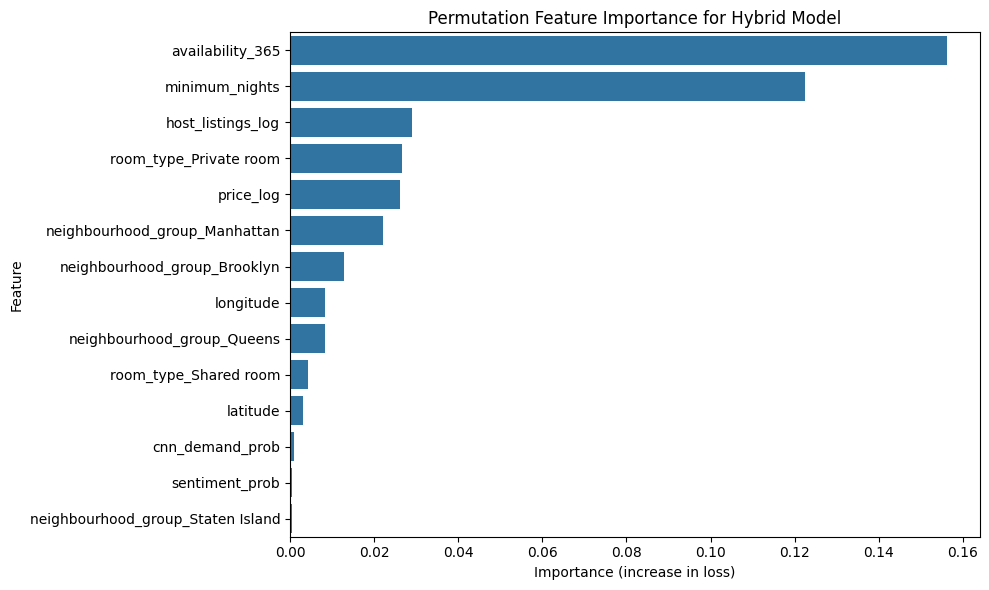

In [521]:
try:
    import eli5
except ImportError:
    !pip install eli5
    import eli5

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='eli5')

# Helper function to compute permutation importance for a PyTorch model
def get_permutation_importance_pytorch(model, X_test, y_test, criterion, n_iter=5):
    model.eval()
    original_loss = criterion(model(torch.tensor(X_test).to(DEVICE)), torch.tensor(y_test).to(DEVICE)).item()

    feature_importances = {}
    for i in range(X_test.shape[1]):
        losses = []
        for _ in range(n_iter):
            X_test_permuted = X_test.copy()
            np.random.shuffle(X_test_permuted[:, i])
            permuted_loss = criterion(
                model(torch.tensor(X_test_permuted).to(DEVICE)),
                torch.tensor(y_test).to(DEVICE)
            ).item()
            losses.append(permuted_loss)
        feature_importances[i] = np.mean(losses) - original_loss
    return feature_importances

# Get feature names after one-hot encoding
def get_feature_names(preprocessor, feature_cols):
    numeric_cols = [c for c in feature_cols if c in BASE_NUMERIC_FEATURES + AUX_FEATURES]
    categorical_cols = [c for c in feature_cols if c in CATEGORICAL_FEATURES]

    feature_names = []
    # Add numeric feature names directly
    feature_names.extend(numeric_cols)

    # Add one-hot encoded categorical feature names
    if 'cat' in [name for name, _, _ in preprocessor.transformers]:
        ohe_transformer = preprocessor.named_transformers_['cat']
        if hasattr(ohe_transformer, 'get_feature_names_out'):
            feature_names.extend(ohe_transformer.get_feature_names_out(categorical_cols))
        else:
            # Fallback for older scikit-learn versions or if get_feature_names_out is not available
            for col_idx, col_name in enumerate(categorical_cols):
                unique_categories = preprocessor.named_transformers_['cat'].categories_[col_idx]
                for cat in unique_categories[1:]:
                    feature_names.append(f"{col_name}_{cat}")

    return feature_names

feature_names = get_feature_names(hybrid_preprocessor, HYBRID_FEATURES)

# Define the criterion used for training the hybrid model
criterion_hybrid = nn.BCEWithLogitsLoss().to(DEVICE)

print("Calculating permutation importance for the Hybrid Model (this may take a moment)...")
perm_importance = get_permutation_importance_pytorch(hybrid_model, X_hybrid_test, y_test, criterion_hybrid, n_iter=10)

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': [perm_importance[i] for i in range(len(feature_names))]
})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("\nPermutation Feature Importance:")
display(feature_importance_df)

# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Permutation Feature Importance for Hybrid Model')
plt.xlabel('Importance (increase in loss)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Hybrid Model ROC Curve

Hybrid Model Test ROC-AUC: 0.8372


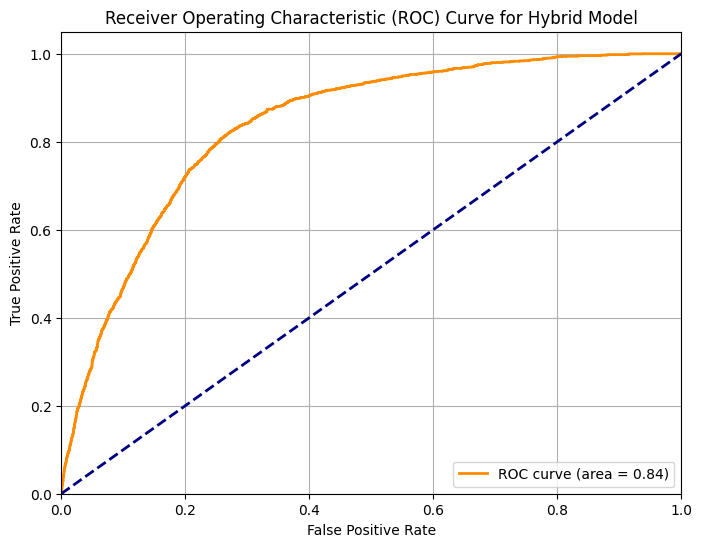

In [522]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Get true labels and predicted probabilities for the hybrid model test set
# These were already computed in the previous section:
# y_test (true labels)
# hybrid_test_prob (predicted probabilities)

# Calculate ROC AUC score for the hybrid model
hybrid_roc_auc = roc_auc_score(y_test, hybrid_test_prob)
print(f"Hybrid Model Test ROC-AUC: {hybrid_roc_auc:.4f}")

# Plot ROC Curve for the hybrid model
fpr_hybrid, tpr_hybrid, thresholds_hybrid = roc_curve(y_test, hybrid_test_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr_hybrid, tpr_hybrid, color='darkorange', lw=2, label=f'ROC curve (area = {hybrid_roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Hybrid Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# You can also display the confusion matrix again if desired
# cm_hybrid = confusion_matrix(y_test, hybrid_test_pred)
# print("\nHybrid Model Test Confusion Matrix:")
# print(cm_hybrid)

# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_hybrid, annot=True, fmt='d', cmap='Blues', cbar=False,
#             xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix for Hybrid Model')
# plt.show()

## 8. Optional baseline comparison

This trains the same tabular NN without the sentiment/CNN features, so the hybrid result can be compared against a structured-only baseline.

In [523]:
baseline_preprocessor = build_preprocessor(BASELINE_FEATURES)
X_baseline = baseline_preprocessor.fit_transform(hybrid_train_df[BASELINE_FEATURES]).astype(np.float32)
X_baseline_test = baseline_preprocessor.transform(test_df[BASELINE_FEATURES]).astype(np.float32)

baseline_model = train_tabular_model(X_baseline, y_hybrid, model_name="baseline_tabular_model")
baseline_test_prob = predict_tabular_prob(baseline_model, X_baseline_test)
baseline_test_pred = (baseline_test_prob >= 0.5).astype(int)

baseline_accuracy = accuracy_score(y_test, baseline_test_pred)
baseline_auc = roc_auc_score(y_test, baseline_test_prob) if len(np.unique(y_test)) > 1 else np.nan

comparison = pd.DataFrame({
    "model": ["Baseline tabular PyTorch model", "Hybrid PyTorch model + sentiment + CNN"],
    "test_accuracy": [baseline_accuracy, hybrid_accuracy],
    "test_roc_auc": [baseline_auc, hybrid_auc],
})
comparison


baseline_tabular_model epoch 1/20 - loss=0.5030, val_acc=0.7699, val_auc=0.7917
baseline_tabular_model epoch 2/20 - loss=0.4650, val_acc=0.7729, val_auc=0.8081
baseline_tabular_model epoch 3/20 - loss=0.4570, val_acc=0.7816, val_auc=0.8142
baseline_tabular_model epoch 4/20 - loss=0.4495, val_acc=0.7824, val_auc=0.8136
baseline_tabular_model epoch 5/20 - loss=0.4459, val_acc=0.7888, val_auc=0.8159
baseline_tabular_model epoch 6/20 - loss=0.4419, val_acc=0.7908, val_auc=0.8221
baseline_tabular_model epoch 7/20 - loss=0.4391, val_acc=0.7878, val_auc=0.8192
baseline_tabular_model epoch 8/20 - loss=0.4357, val_acc=0.7924, val_auc=0.8240
baseline_tabular_model epoch 9/20 - loss=0.4338, val_acc=0.7924, val_auc=0.8257
baseline_tabular_model epoch 10/20 - loss=0.4332, val_acc=0.7939, val_auc=0.8271
baseline_tabular_model epoch 11/20 - loss=0.4316, val_acc=0.7939, val_auc=0.8285
baseline_tabular_model epoch 12/20 - loss=0.4291, val_acc=0.7942, val_auc=0.8291
baseline_tabular_model epoch 13/20 - 

,model,test_accuracy,test_roc_auc
0,Baseline tabular PyTorch model,0.792881,0.837239
1,Hybrid PyTorch model + sentiment + CNN,0.791142,0.837209


## 9. Save test predictions

This creates a CSV with the hybrid prediction, the two auxiliary features, and the true high-demand label.

In [ ]:
output_cols = ["high_demand", "sentiment_prob", "cnn_demand_prob"]
for optional_col in ["id", "name", "neighbourhood_group", "neighbourhood", "room_type", "price"]:
    if optional_col in test_df.columns:
        output_cols.insert(0, optional_col)

test_predictions = test_df[output_cols].copy()
test_predictions["hybrid_high_demand_prob"] = hybrid_test_prob
test_predictions["hybrid_high_demand_pred"] = hybrid_test_pred

pred_path = "hybrid_airbnb_test_predictions.csv"
test_predictions.to_csv(pred_path, index=False)
print(f"Saved predictions to {pred_path}")
test_predictions.head()
